In [46]:
import itertools as itt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from common import FEATURES_OUTFILE
from dmm.initialisation import get_features, pca_transform_features
from sklearn.decomposition import PCA, SparsePCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, MultiTaskElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from typing import Union


In [2]:
# Set up some hyperparams
samples = "0of5"
target_context = "cytof_dynamic"

# Need tuning -- number of pca components to keep in target + to keep in input
num_pca_target = 2  
num_pca_input = 0.95  # keep 95% of variance

input_context = "cytof_init"

In [47]:
def get_pca_features(samples: str, num_components: Union[int, float], context: str, scale: bool = False, impute: bool = False, whiten: bool = True): 
    # Set up minimal conf
    target_conf_dict = {
        "model": "EGFR_MAPK",
        "data": "dream_cytof", 
        "samples": samples, 
        "features": "all", 
        "context": context,  # fixed target context
    }
    
    # Define filepath for features file
    features_filepath = FEATURES_OUTFILE.format(
        **{**target_conf_dict, **dict(dataset = "{dataset}")}
    )
    
    features = get_features(features_filepath=features_filepath, datasets=["train", "val"])
    
    steps = []
    if scale: 
        steps.append(('scale', StandardScaler(with_std=False)))
    if impute: 
        steps.append(('impute', KNNImputer()))
    steps.append(
        ('pca', PCA(
            n_components=num_components,  # keep all
            whiten=whiten, 
        ))
    )
    
    pipeline = Pipeline(steps)
    
    # fit on training features
    pipeline.fit(features["train"])
    
    # transform both train and val and return
    transformed_features = {
        dataset: pd.DataFrame(
            pipeline.transform(features[dataset]),
            index=features[dataset].index,
            columns=[f'pca_{i}' for i in range(pipeline.named_steps['pca'].n_components_)]
        )
        for dataset in features.keys()
    }
    return transformed_features, pipeline.named_steps['pca'].n_components_

In [4]:
def rmse(data: np.ndarray, pred: np.ndarray) -> float: 
    return np.sqrt(np.mean(np.square(data - pred)))

In [5]:
targets, _ = get_pca_features(samples, num_pca_target, context=target_context, impute=True)  # dict with keys "train" and "val"

In [6]:
inputs, _ = get_pca_features(samples, num_pca_input, context=input_context, impute=True)  # missing features (NaNs) -> impute

In [7]:
# Experiment 1: simple LinearRegression
lr = LinearRegression()
lr.fit(inputs["train"], targets["train"])

rmse(targets["val"], lr.predict(inputs["val"]))

1.1446355258279801

In [8]:
def linreg_experiment(input_context: str, num_pca_input, target_context: str, num_pca_target): 
    # Get input features - handle imputation
    try:
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context)
    except ValueError: 
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context, impute=True)
    
    # Get target features
    try:
        targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context)
    except ValueError: 
        targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context, impute=True)
    
    # print("Features extracted")
    # 
    # Instantiate linear regressor and fit
    lr = LinearRegression()
    lr.fit(inputs["train"], targets["train"])
    
    # Compute RMSEs
    rmse_train, rmse_val = [
        rmse(targets[dataset], lr.predict(inputs[dataset]))
        for dataset in ["train", "val"]
    ]
    # print(f'RMSE train: {rmse_train}, RMSE validation: {rmse_val}')
    # print("RMSE computed")
    return (rmse_train, rmse_val), (pca_components_input, pca_components_target)

In [9]:
def elasticnet_experiment(input_context: str, num_pca_input, target_context: str, num_pca_target): 
    # Get input features - handle imputation
    try:
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context)
    except ValueError: 
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context, impute=True)
    
    # Get target features
    try:
        targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context)
    except ValueError: 
        targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context, impute=True)
    
    # print("Features extracted")
    # 
    # Instantiate linear regressor and fit
    regressor = MultiTaskElasticNetCV()
    regressor.fit(inputs["train"], targets["train"])
    
    # Compute RMSEs
    rmse_train, rmse_val = [
        rmse(targets[dataset], regressor.predict(inputs[dataset]))
        for dataset in ["train", "val"]
    ]
    # print(f'RMSE train: {rmse_train}, RMSE validation: {rmse_val}')
    # print("RMSE computed")
    return (rmse_train, rmse_val), (pca_components_input, pca_components_target)

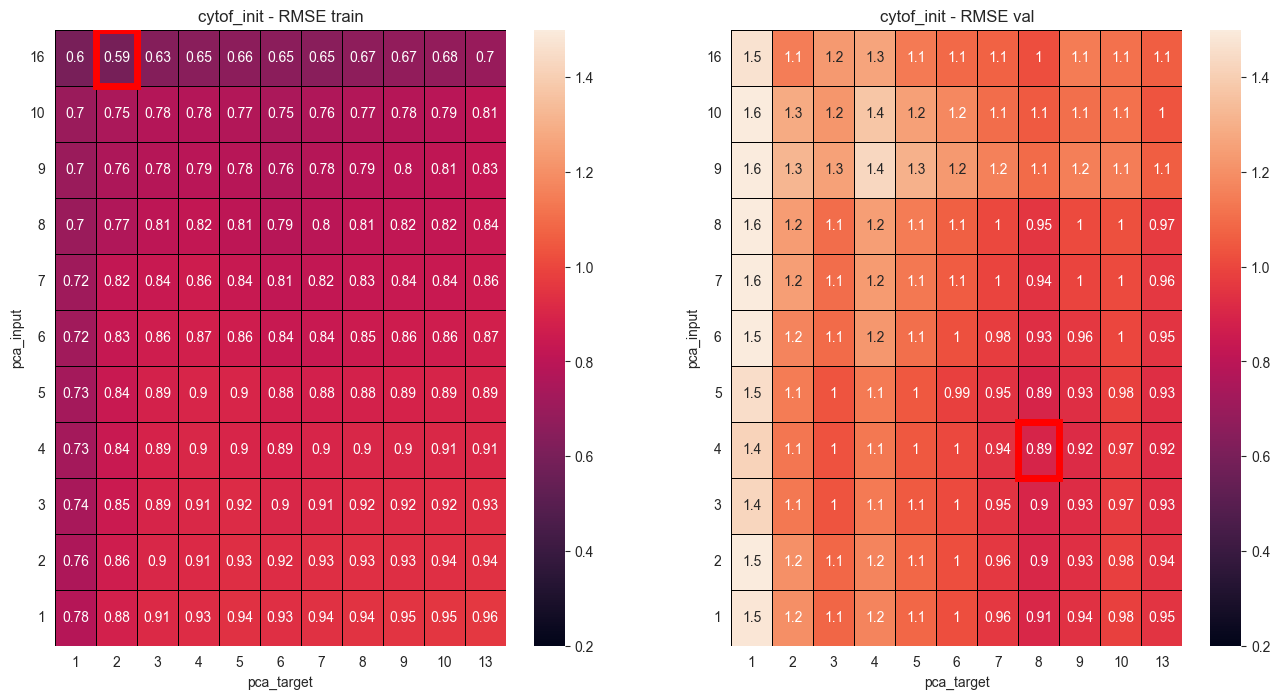

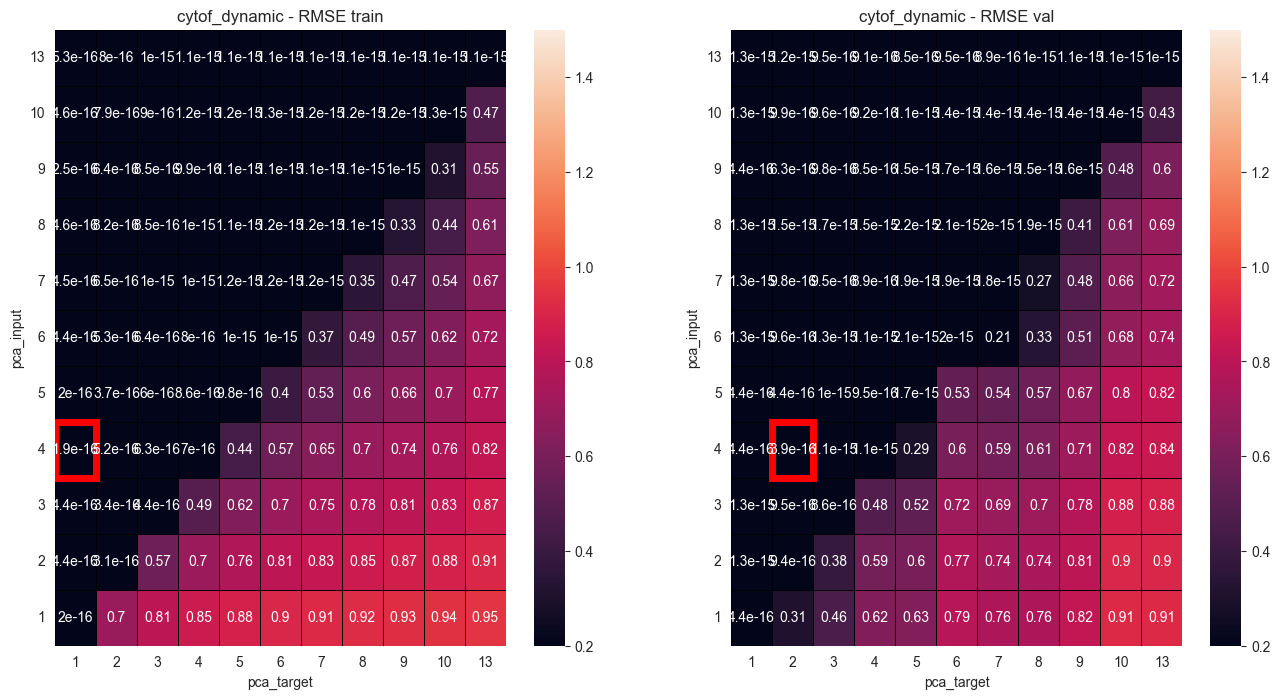

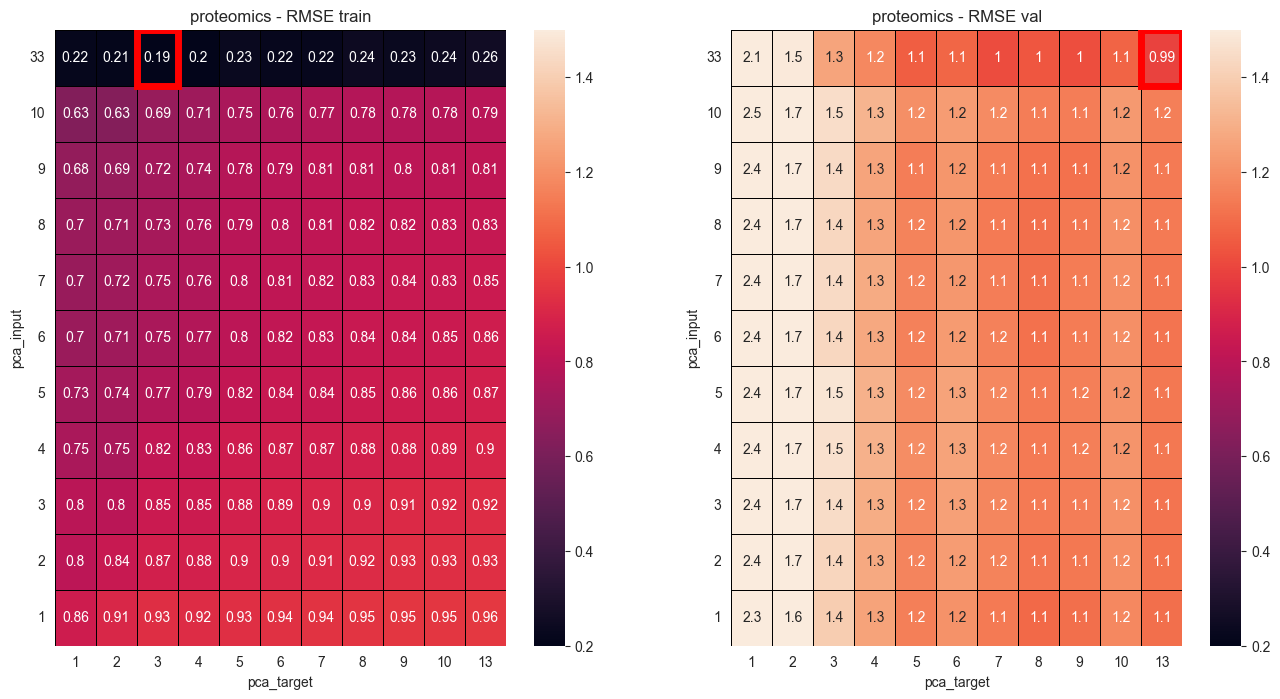

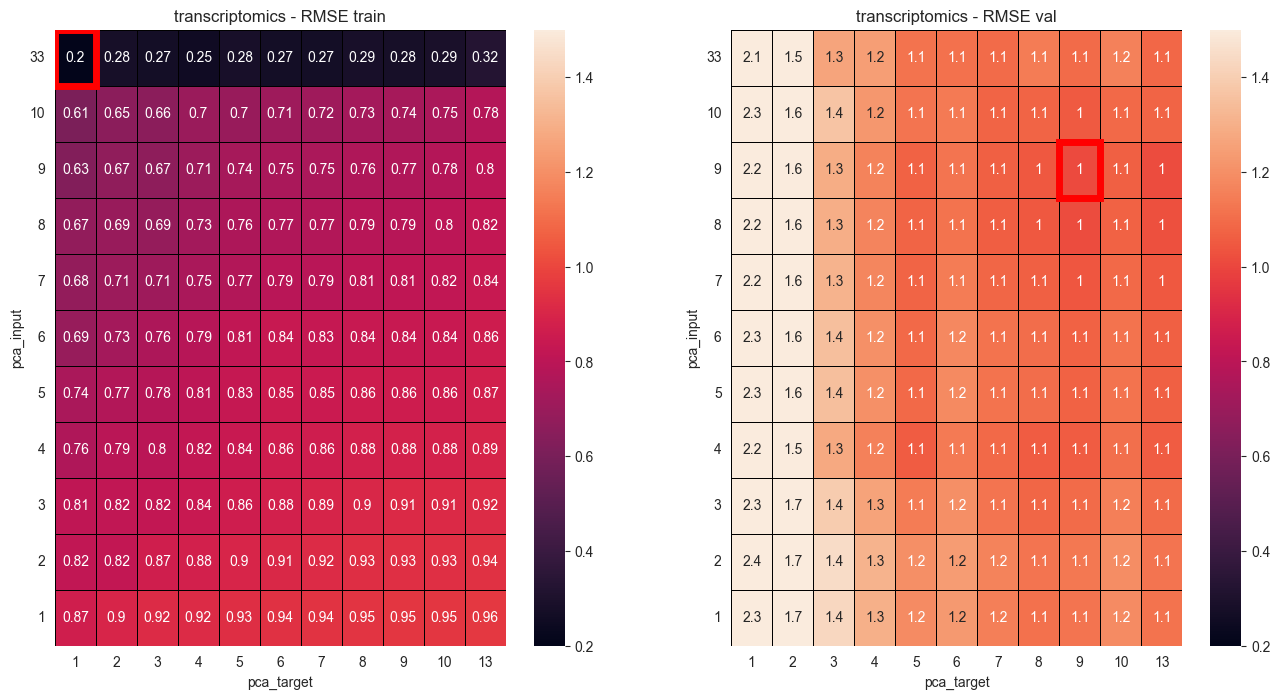

In [28]:
for input_context in ["cytof_init", "cytof_dynamic", "proteomics", "transcriptomics"]:
    results = {"train": {}, "val": {}}
    for num_pca_input, num_pca_target in itt.product(
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
    ): 
        (rmse_train, rmse_val), (pca_input, pca_target) = linreg_experiment(input_context, num_pca_input, target_context, num_pca_target)
        results["train"][(pca_input, pca_target)] = rmse_train
        results["val"][(pca_input, pca_target)] = rmse_val
    
    norm = mcolors.Normalize(vmin=0.2, vmax=1.5) 
    # Create the heatmap
    plt.subplots(1, 2, figsize=(16, 8))
    for ind, dataset in enumerate(results.keys()):
        # Convert the results dictionary into a pandas DataFrame
        df = pd.DataFrame.from_dict(results[dataset], orient='index', columns=['RMSE'])
        df.index = pd.MultiIndex.from_tuples(df.index, names=['pca_input', 'pca_target'])
        
        # Reset index to turn the index into columns if needed
        df = df.reset_index()
        # pivot the dataframe
        pivot_df = df.pivot(index='pca_input', columns='pca_target', values='RMSE')
        
        plt.subplot(1, 2, ind+1)
        ax = plt.gca()
        ax = sns.heatmap(pivot_df, linewidths=0.5, linecolor='black', annot=True, cbar=True, norm=norm)
        ax.invert_yaxis()
        # Find the location of the minimum value
        min_value = pivot_df.min().min()
        min_location = np.where(pivot_df == min_value)
        
        plt.yticks(rotation=0)
        
        # Draw a rectangle around the cell with the minimum value
        for y, x in zip(*min_location):
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=5))
        ax.set_title(f'{input_context} - RMSE {dataset}')
    plt.savefig(f'linreg_{input_context}_{target_context}_PCA_LOOCV.png')
    plt.show()

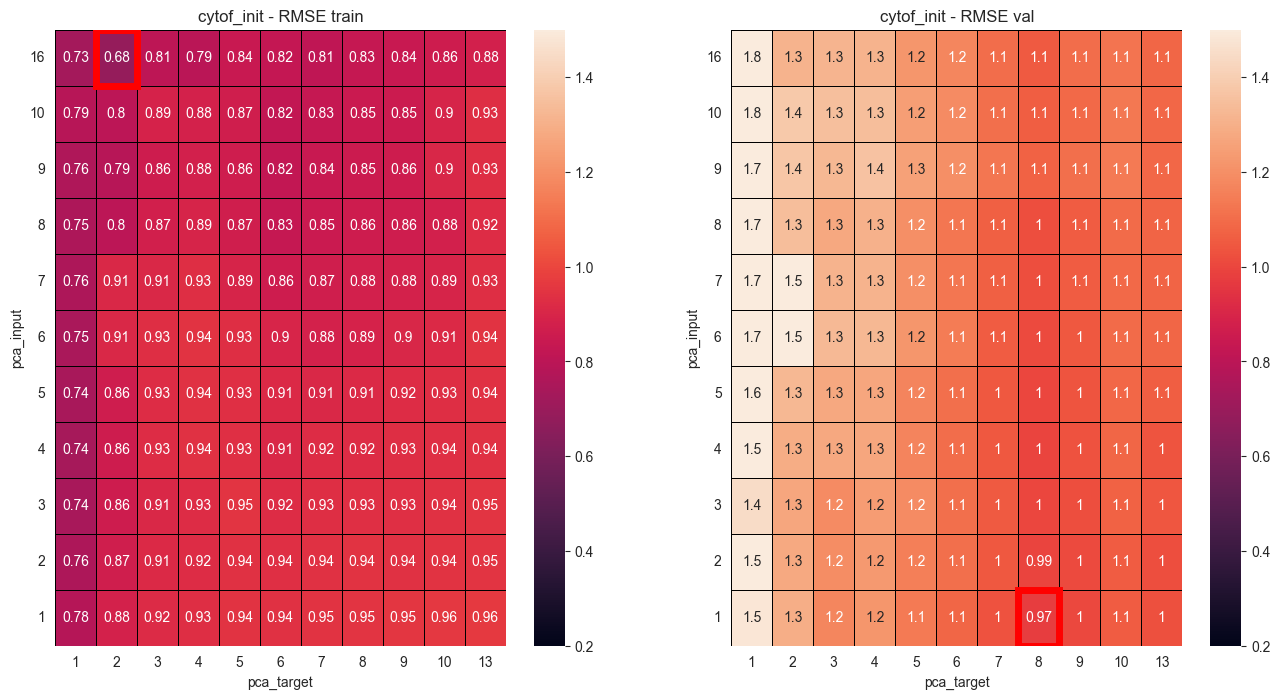

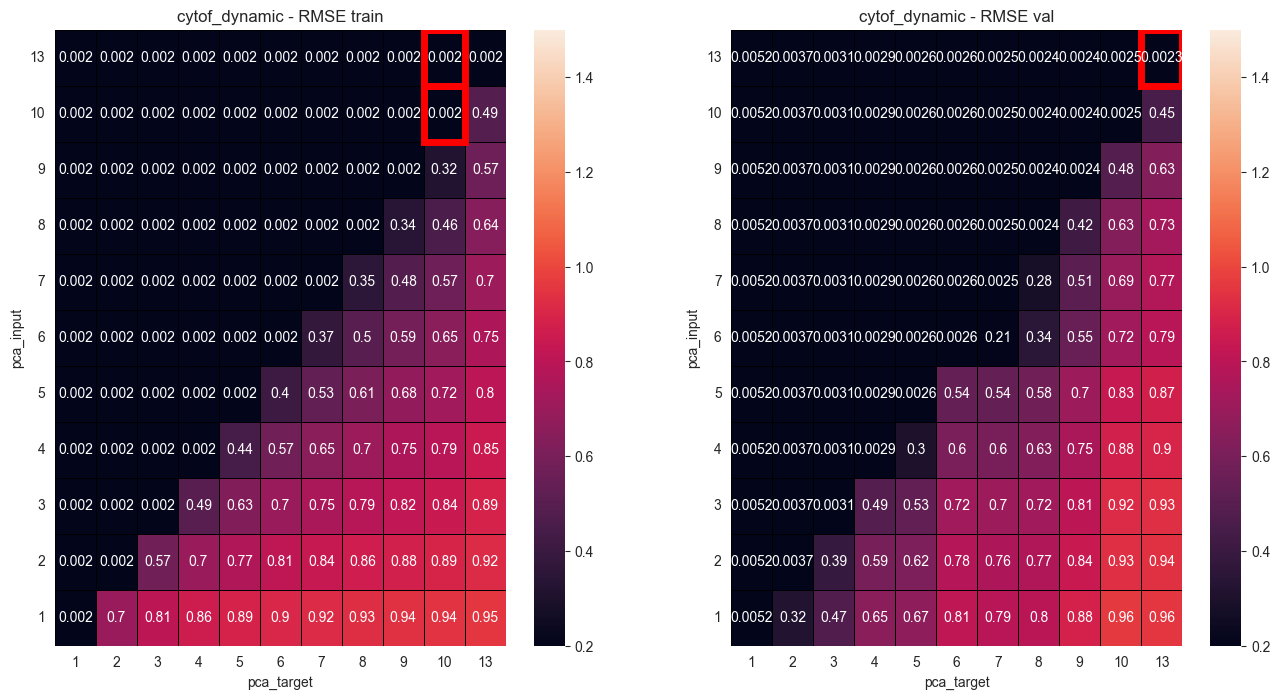

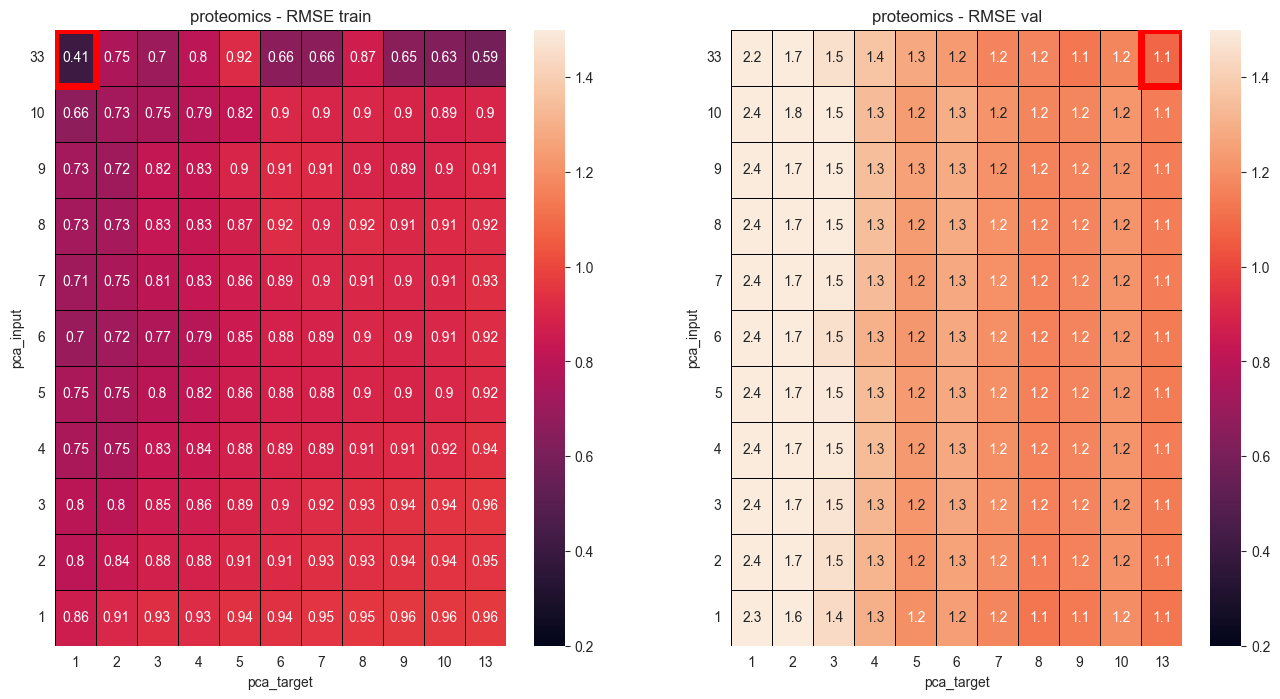

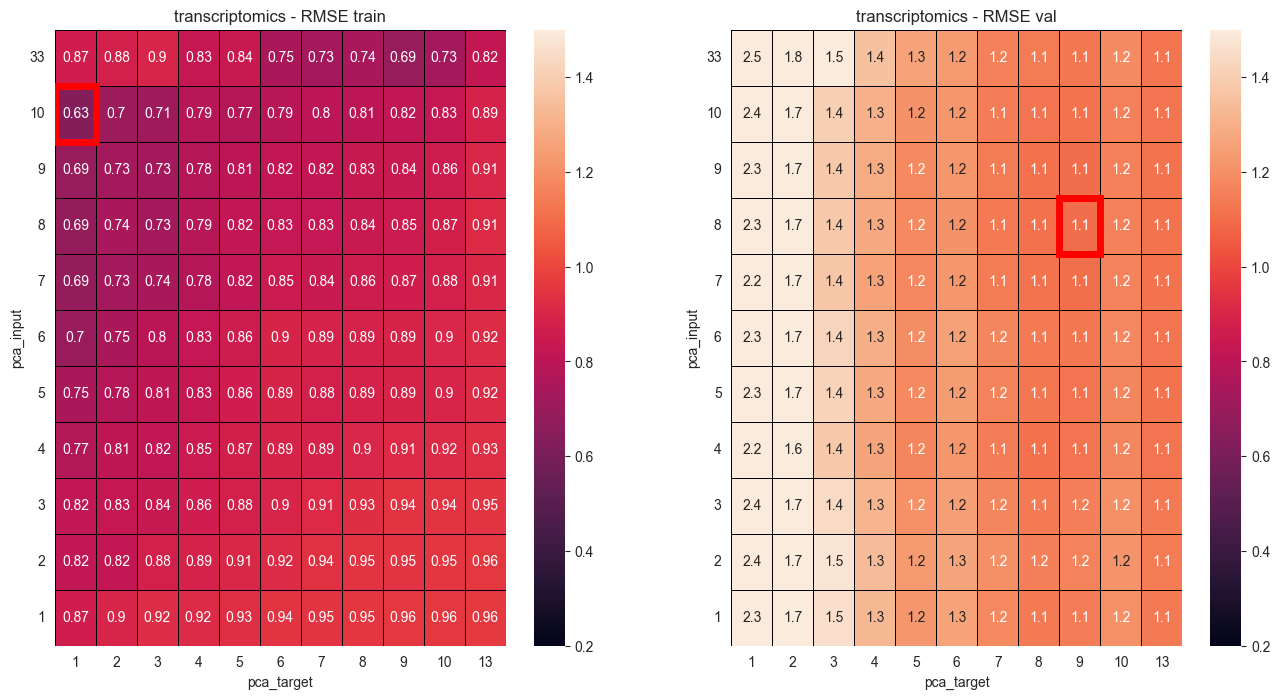

In [29]:
for input_context in ["cytof_init", "cytof_dynamic", "proteomics", "transcriptomics"]:
    results = {"train": {}, "val": {}}
    for num_pca_input, num_pca_target in itt.product(
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
    ): 
        (rmse_train, rmse_val), (pca_input, pca_target) = elasticnet_experiment(input_context, num_pca_input, target_context, num_pca_target)
        results["train"][(pca_input, pca_target)] = rmse_train
        results["val"][(pca_input, pca_target)] = rmse_val
    
    norm = mcolors.Normalize(vmin=0.2, vmax=1.5) 
    # Create the heatmap
    plt.subplots(1, 2, figsize=(16, 8))
    for ind, dataset in enumerate(results.keys()):
        # Convert the results dictionary into a pandas DataFrame
        df = pd.DataFrame.from_dict(results[dataset], orient='index', columns=['RMSE'])
        df.index = pd.MultiIndex.from_tuples(df.index, names=['pca_input', 'pca_target'])
        
        # Reset index to turn the index into columns if needed
        df = df.reset_index()
        # pivot the dataframe
        pivot_df = df.pivot(index='pca_input', columns='pca_target', values='RMSE')
        
        plt.subplot(1, 2, ind+1)
        ax = plt.gca()
        ax = sns.heatmap(pivot_df, linewidths=0.5, linecolor='black', annot=True, cbar=True, norm=norm)
        ax.invert_yaxis()
        # Find the location of the minimum value
        min_value = pivot_df.min().min()
        min_location = np.where(pivot_df == min_value)
        
        plt.yticks(rotation=0)
        
        # Draw a rectangle around the cell with the minimum value
        for y, x in zip(*min_location):
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=5))
        ax.set_title(f'{input_context} - RMSE {dataset}')
    plt.savefig(f'MTelasticnet_{input_context}_{target_context}_PCA_LOOCV.png')
    plt.show()

In [10]:
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import optax
import tqdm

from jax.nn import tanh, relu, swish
from jax import vmap


def train_MLP(
        samples: str, 
        input_context: str, num_pca_input, 
        target_context: str, num_pca_target, 
        depth: int, width: int, activation_fn_name: str, 
        l1reg_scale: float=0, 
        lr: float = 1e-3, weight_decay: float = 1e-4,
        num_epochs: int = 1000,
): 
    # Get input features - handle imputation
    try:
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context)
    except ValueError: 
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context, impute=True)
    
    # Get target features - handle imputation
    try:
        targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context)
    except ValueError: 
        targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context, impute=True)
    
    # Compute input/output sizes for MLP
    input_size = pca_components_input
    output_size = pca_components_target
    
    print(input_size, output_size)
    
    # Define activation functions
    activations = {
        "relu": relu, 
        "swish": swish, 
        "tanh": tanh, 
        "identity": lambda x: x, 
    }
    
    # create MLP instance (default initialisation)
    mlp = eqx.nn.MLP(
        in_size=input_size, 
        out_size=output_size, 
        width_size=width, 
        depth=depth, 
        activation=activations[activation_fn_name], 
        key=jr.PRNGKey(0),
    )
    
    # Define optimizer
    opt = optax.adamw(learning_rate=lr, weight_decay=weight_decay)
    # Get diff and static
    diff_model, static_model = eqx.partition(mlp, eqx.is_array)
    # Initialise optimizer state
    opt_state = opt.init(diff_model)
    
    @eqx.filter_jit
    def jax_rmse(data: jnp.ndarray, pred: jnp.ndarray) -> float: 
        return jnp.sqrt(jnp.mean(jnp.square(data - pred)))
    
    @eqx.filter_jit
    def MLP_loss(diff_model, static_model, input_data, target_data):
        model = eqx.combine(diff_model, static_model)
        return jax_rmse(target_data, vmap(model)(input_data))
    
    def l1reg(model): 
        reg = 0
        for layer in model.layers: 
            reg += jnp.mean(jnp.abs(layer.weight))
        return reg/len(model.layers)
    
    @eqx.filter_value_and_grad
    def MLP_loss_and_grad(diff_model, static_model, input_data, target_data, l1reg_scale=0):
        model = eqx.combine(diff_model, static_model)
        return jax_rmse(target_data, vmap(model)(input_data)) + l1reg_scale*l1reg(model)
    
    @eqx.filter_jit
    def make_MLP_step(diff_model, static_model, opt, opt_state, input_data, target_data):
        loss, grads = MLP_loss_and_grad(
            diff_model, 
            static_model,
            input_data,
            target_data, 
            l1reg_scale, 
        )
        updates, opt_state = opt.update(grads, opt_state, diff_model)
        # Update model in `next_model`, but keep current one in `model` for current epoch metric logging
        diff_model = eqx.apply_updates(diff_model, updates)
        return diff_model, static_model, opt_state, loss, grads
    
    loss_train_history, loss_val_history = [], []
    
    # Train the model
    for epoch in tqdm.tqdm(range(num_epochs)): 
        diff_model, static_model, opt_state, loss, grads = make_MLP_step(
            diff_model, static_model, 
            opt, opt_state, 
            inputs["train"].values, targets["train"].values
        )
        loss_train_history.append(loss)
        
        if epoch % 25 == 0: 
            loss_val = MLP_loss(diff_model, static_model, inputs["val"].values, targets["val"].values)
            loss_val_history.append(loss_val)
            # print(f'Epoch {epoch} - Training Loss: {loss} - Validation Loss: {loss_val}')
            
    return eqx.combine(diff_model, static_model), loss_train_history, loss_val_history
    

16 13


100%|██████████| 10000/10000 [00:05<00:00, 1823.90it/s]


Text(0.5, 1.0, 'cytof_init -> cytof_dynamic')

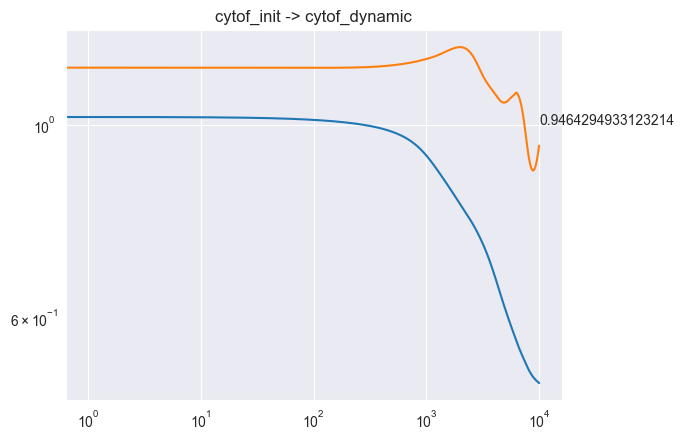

In [11]:
model, loss_train_history, loss_val_history = train_MLP(
    samples="0of5", 
    input_context="cytof_init", num_pca_input=0.95, 
    target_context="cytof_dynamic", num_pca_target=0.95, 
    depth=2, width=10, activation_fn_name="swish", 
    l1reg_scale=0, 
    lr=1e-4, weight_decay=0.001, 
    num_epochs=10000
)

plt.plot(np.arange(0, 10000), loss_train_history)
plt.plot(np.arange(0, 10000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("cytof_init -> cytof_dynamic")

33 13


100%|██████████| 10000/10000 [00:04<00:00, 2121.86it/s]


Text(0.5, 1.0, 'proteomics -> cytof_dynamic')

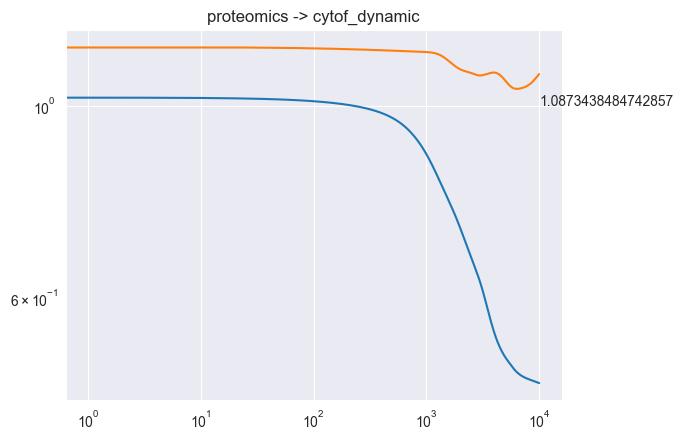

In [12]:
model, loss_train_history, loss_val_history = train_MLP(
    samples="0of5", 
    input_context="proteomics", num_pca_input=0.95, 
    target_context="cytof_dynamic", num_pca_target=0.95, 
    depth=2, width=10, activation_fn_name="swish", 
    l1reg_scale=0, 
    lr=1e-4, weight_decay=0.001, 
    num_epochs=10000
)

plt.plot(np.arange(0, 10000), loss_train_history)
plt.plot(np.arange(0, 10000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("proteomics -> cytof_dynamic")

33 13


100%|██████████| 12000/12000 [00:04<00:00, 2629.10it/s]


Text(0.5, 1.0, 'transcriptomics -> cytof_dynamic')

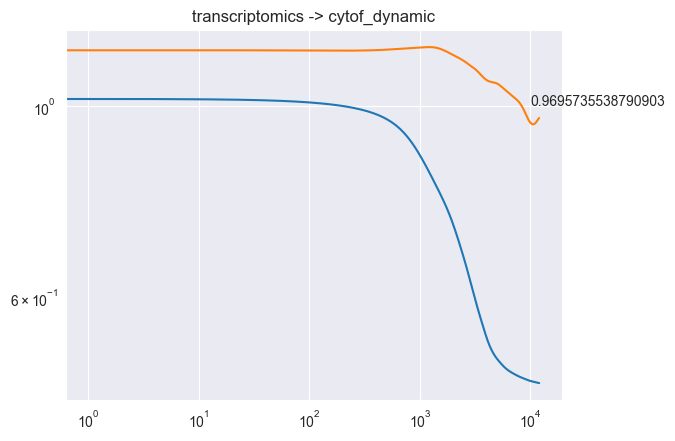

In [13]:
model, loss_train_history, loss_val_history = train_MLP(
    samples="0of5", 
    input_context="transcriptomics", num_pca_input=0.95, 
    target_context="cytof_dynamic", num_pca_target=0.95, 
    depth=2, width=10, activation_fn_name="swish", 
    l1reg_scale=0, 
    lr=1e-4, weight_decay=0.001, 
    num_epochs=12000
)

plt.plot(np.arange(0, 12000), loss_train_history)
plt.plot(np.arange(0, 12000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("transcriptomics -> cytof_dynamic")

13 13


100%|██████████| 12000/12000 [00:04<00:00, 2549.86it/s]


Text(0.5, 1.0, 'cytof_dynamic -> cytof_dynamic')

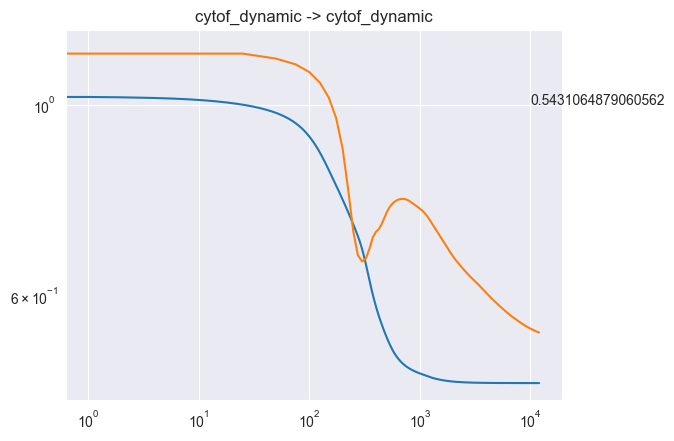

In [14]:
# Last resort: cytof_dynamic -> cytof_dynamic -- can only learn an identity mapping through heavy regularisation + no depth (single linear layer, no activation function)
model, loss_train_history, loss_val_history = train_MLP(
    samples="0of5",
    input_context="cytof_dynamic", num_pca_input=0.95,
    target_context="cytof_dynamic", num_pca_target=0.95,
    depth=2, width=10, activation_fn_name="swish",
    l1reg_scale=0,
    lr=1e-3, weight_decay=0.001,
    num_epochs=12000
)

plt.plot(np.arange(0, 12000), loss_train_history)
plt.plot(np.arange(0, 12000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("cytof_dynamic -> cytof_dynamic")

In [16]:
from sklearn.base import BaseEstimator, RegressorMixin
import jax.random
import optax


def rmse_loss(model, x, y):
    pred = jax.vmap(model)(x)
    return jnp.sqrt(jnp.mean((pred - y) ** 2))


def train_step(model, optimizer, x, y, opt_state):
    loss, grads = eqx.filter_value_and_grad(rmse_loss)(model, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


class EquinoxMLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size, out_size, width_size=50, depth=3, learning_rate=1e-3, num_epochs=100, key=None):
        self.in_size = in_size
        self.out_size = out_size
        self.width_size = width_size
        self.depth = depth
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.key = key if key is not None else jax.random.PRNGKey(0)
        self.model = None
        self.opt_state = None

    def fit(self, X, y):
        # Create model
        key, subkey = jax.random.split(self.key)
        self.model = eqx.nn.MLP(
            in_size=self.in_size, 
            out_size=self.out_size, 
            width_size=self.width_size, 
            depth=self.depth, 
            key=subkey
        )
        
        # Define optimizer
        optimizer = optax.adam(learning_rate=self.learning_rate)
        self.opt_state = optimizer.init(eqx.filter(self.model, eqx.is_array))
        
        # Training loop
        for epoch in range(self.num_epochs):
            self.model, self.opt_state, _ = train_step(self.model, optimizer, X, y, self.opt_state)
        
        return self

    def predict(self, X):
        return jax.vmap(self.model)(X)

    def score(self, X, y):
        # Here, we use the negative MSE as a score for maximization
        return -rmse_loss(self.model, X, y)

In [42]:
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV

inputs, pca_components_input = get_pca_features(samples, 0.95, context="transcriptomics", impute=True)
targets, pca_components_target = get_pca_features(samples, 0.95, context="cytof_dynamic", impute=True)

x_train, y_train = inputs["train"].values, targets["train"].values
x_val, y_val = inputs["val"].values, targets["val"].values
# x = np.concatenate([x_train, x_val])
# y = np.concatenate([y_train, y_val])

# tot = pd.concat([inputs["train"], inputs["val"]]).reset_index()
# hardest_samples = ['cMCF7', 'cBT20', 'cHCC1500', 'cEVSAT', 'cHCC2185']
# val_idx = [tot.index[tot.preequilibrationConditionId == sample].values[0] for sample in hardest_samples]
# cv_num = [0, 1, 2, 3, 4]
# cv_scheme = [-1] * (len(x_train) + len(x_val))
# for ind, idx in enumerate(val_idx):
#     cv_scheme[idx] = cv_num[ind]

# ps = PredefinedSplit([-1] * len(x_train) + [0] * len(x_val))  # only the single sample in x_val is used for validation
# ps = PredefinedSplit(cv_scheme)

# Define the hyperparameter space
param_dist = {
    'width_size': [10, 20, 50, 100],
    'depth': [1, 3, 5, 7],
    'learning_rate': [1e-4, 1e-3, 1e-2, 1e-1],
    'num_epochs': [50, 100, 200, 500]
}

# Create an instance of the wrapper
mlp_wrapper = EquinoxMLPWrapper(
    in_size=pca_components_input, 
    out_size=pca_components_target, 
    key=jax.random.PRNGKey(42)
)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=mlp_wrapper, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3,  # replace with ps to use ps
    scoring='neg_mean_squared_error', 
    random_state=42, 
    verbose=10
)

# Fit the RandomizedSearchCV
random_search.fit(x_train, y_train)

# Best model and parameters
best_model = random_search.best_estimator_
best_params = random_search.best_params_

print("Best Hyperparameters:", best_params)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START depth=7, learning_rate=0.01, num_epochs=100, width_size=10.
[CV 1/5; 1/10] END depth=7, learning_rate=0.01, num_epochs=100, width_size=10;, score=-1.489 total time=   2.2s
[CV 2/5; 1/10] START depth=7, learning_rate=0.01, num_epochs=100, width_size=10.
[CV 2/5; 1/10] END depth=7, learning_rate=0.01, num_epochs=100, width_size=10;, score=-1.007 total time=   1.8s
[CV 3/5; 1/10] START depth=7, learning_rate=0.01, num_epochs=100, width_size=10.


KeyboardInterrupt: 

In [39]:
# Now the model 
print(f"RMSE train: {-random_search.best_estimator_.score(x_train, y_train)}")
print(f"RMSE val: {-random_search.best_estimator_.score(x_val, y_val)}")  

RMSE train: 0.9614115257307205
RMSE val: 1.1221987316782178


33 13


100%|██████████| 100/100 [00:00<00:00, 428.84it/s]


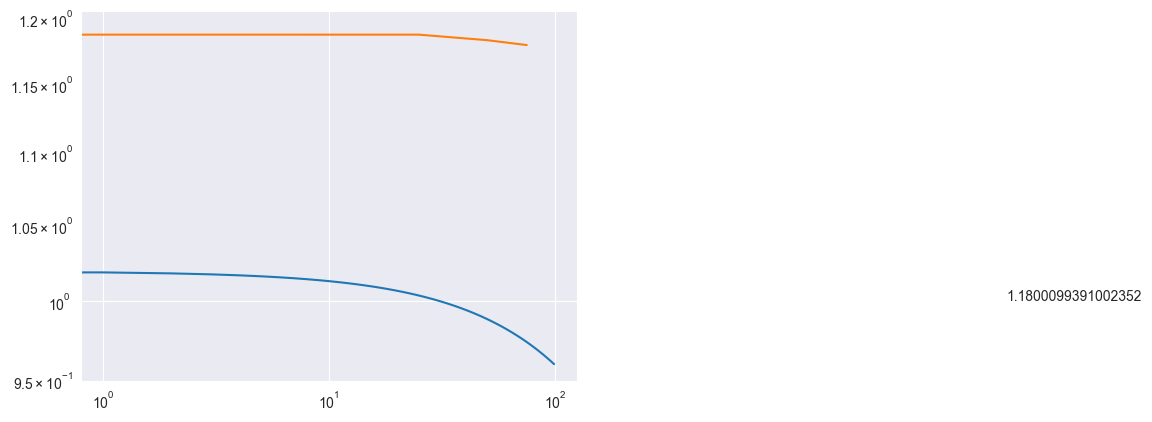

In [40]:
# Verify (AdamW with 0 weight_decay is just Adam) -> 0.915, 1.16 vs 0.925, 1.185 -- might just be related to random init of the layer weights
model, loss_train_history, loss_val_history = train_MLP(
    samples="0of5",
    input_context="transcriptomics", num_pca_input=0.95,
    target_context="cytof_dynamic", num_pca_target=0.95,
    depth=1, width=50, 
    activation_fn_name="relu",  # default ReLU activation in MLP
    l1reg_scale=0,
    lr=0.0001, weight_decay=0,
    num_epochs=100
)
plt.plot(np.arange(0, 100), loss_train_history)
plt.plot(np.arange(0, 100, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')

In [57]:
import jax.random
import numpy as np

# Define a function to sample random hyperparameters
def sample_hyperparameters(seed: int):
    np.random.seed(seed)
    depth = np.random.randint(1, 10)  # Number of layers
    width_size = np.random.randint(10, 100)  # Number of neurons per layer
    learning_rate = 10 ** np.random.uniform(-4, -1)  # Learning rate
    return depth, width_size, learning_rate

# Define the random search function
def random_search(num_trials, in_size, out_size, key, x_train, y_train, x_val, y_val, num_epochs=500):
    best_model = None
    best_loss = np.inf
    best_hyperparams = None
    
    for i in range(num_trials):
        # Sample random hyperparameters
        depth, width_size, learning_rate = sample_hyperparameters(seed=i)
        
        # Create model
        key, subkey = jax.random.split(key)
        model = eqx.nn.MLP(
            in_size=in_size, out_size=out_size, 
            width_size=width_size, depth=depth, 
            key=subkey
        )
        
        # Define optimizer
        optimizer = optax.adam(learning_rate)
        opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
        
        # Training loop (assuming you have your data as x_train, y_train)
        for epoch in range(num_epochs):  # For example, train for 100 epochs
            model, opt_state, loss = train_step(model, optimizer, x_train, y_train, opt_state)
        
        loss_val = rmse_loss(model, x_val, y_val)
        
        # Compare with the best model
        if loss_val < best_loss:
            best_loss = loss_val
            best_model = model
            best_hyperparams = (depth, width_size, learning_rate)
        
        #print(f"Trial {i+1}: Loss val={loss_val:.4f}, Depth={depth}, Width={width_size}, Learning Rate={learning_rate:.6f}")
    
    print(f"Best Loss={best_loss:.4f} with Hyperparameters: Depth={best_hyperparams[0]}, Width={best_hyperparams[1]}, Learning Rate={best_hyperparams[2]:.6f}")
    return best_model, best_hyperparams, best_loss

In [58]:
for context, samples in itt.product(
        ["cytof_init", "proteomics", "transcriptomics"], ["0of5", "1of5", "2of5", "3of5", "4of5"]
):
    # input context varies
    inputs, pca_components_input = get_pca_features(samples=samples, num_components=0.95, context=context, impute=True)
    # target context is always cytof_dynamic
    targets, pca_components_target = get_pca_features(samples=samples, num_components=0.95, context="cytof_dynamic", impute=True)
    
    # Prepare arrays for training and validation
    x_train, y_train = inputs["train"].values, targets["train"].values
    x_val, y_val = inputs["val"].values, targets["val"].values
    
    # Hyperparameter search
    key = jax.random.PRNGKey(42)
    print("Context:", context, "Samples:", samples)
    best_model, best_hyperparams, best_val_loss = random_search(
        num_trials=20, 
        in_size=pca_components_input, out_size=pca_components_target, 
        key=key, 
        x_train=x_train, y_train=y_train, 
        x_val=x_val, y_val=y_val
    )

Context: cytof_init Samples: 0of5
Best Loss=0.6880 with Hyperparameters: Depth=3, Width=58, Learning Rate=0.000516
Context: cytof_init Samples: 1of5
Best Loss=1.2538 with Hyperparameters: Depth=6, Width=74, Learning Rate=0.006431
Context: cytof_init Samples: 2of5
Best Loss=0.8176 with Hyperparameters: Depth=6, Width=22, Learning Rate=0.062758
Context: cytof_init Samples: 3of5
Best Loss=0.9675 with Hyperparameters: Depth=6, Width=74, Learning Rate=0.006431
Context: cytof_init Samples: 4of5
Best Loss=1.1764 with Hyperparameters: Depth=9, Width=13, Learning Rate=0.000746
Context: proteomics Samples: 0of5
Best Loss=0.9227 with Hyperparameters: Depth=5, Width=35, Learning Rate=0.000906
Context: proteomics Samples: 1of5
Best Loss=1.3352 with Hyperparameters: Depth=6, Width=64, Learning Rate=0.000105
Context: proteomics Samples: 2of5
Best Loss=0.8645 with Hyperparameters: Depth=3, Width=58, Learning Rate=0.000516
Context: proteomics Samples: 3of5
Best Loss=0.9249 with Hyperparameters: Depth=1